<a href="https://colab.research.google.com/github/p16996/predictive-maintenance-analysis/blob/main/Predictive_Maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Maintenance — Exploratory Analysis

Explored a real-world manufacturing sensor dataset (10,000 readings)
to identify temperature patterns, failure indicators, and anomalies
using statistical detection methods and AI-generated explanations.

## Key findings

**Temperature patterns:**
- Air temperature ranges from ~295K to ~305K with a bimodal
  distribution — two peaks around 298K and 301K suggesting two
  distinct operating modes or machine types in the dataset
- Failed machines operated at a consistently higher median
  temperature (301.6K) vs non-failed machines (300.0K), indicating
  thermal stress as a contributing — not sole — factor in failure

**Failure analysis:**
- Only 3.4% of readings resulted in machine failure, confirming
  failure events are rare and anomaly detection must be highly
  precise to avoid false positives
- 1.1% of readings exceeded the safe operating threshold of 304K
- Torque showed the strongest correlation with failure (0.191)
  among operational sensor variables, followed by tool wear (0.105)
  and air temperature (0.083) — suggesting mechanical stress is a
  stronger failure predictor than thermal conditions alone
- Note: failure mode columns (HDF, OSF, PWF, TWF) were excluded
  from correlation analysis as they are labels recorded at the
  moment of failure, not independent predictors

**Anomaly detection:**
- Z-score (threshold=2) detected 224 anomalies (2.24% of readings)
- IQR (multiplier=0.75) detected 263 anomalies (2.63% of readings)
- 218 readings flagged by both methods — representing highest
  confidence anomalies with 97% agreement between methods
- Standard thresholds (z=3, IQR=1.5) were tuned down because
  temperature drifts gradually in this dataset rather than spiking
  abruptly — threshold selection was validated against the actual
  data distribution
- Top anomalies explained automatically using Claude AI API,
  generating plain-English insights for maintenance engineers

**AI-generated explanations:**
- Built a pipeline using the Anthropic Claude API to automatically
  generate plain-English, 2-sentence explanations for the top
  flagged anomalies — covering what the anomaly indicates and what
  action a maintenance engineer should take
- Designed prompt constraints (sentence count, word limit per
  sentence) and validated output against those constraints to
  ensure consistent, concise results with no truncation
- Tracked real token usage and per-call cost via the Anthropic API
  response, rather than relying on estimates, for accurate cost
  monitoring

## Tools used
Python · Pandas · Matplotlib · Plotly · SciPy · Anthropic Claude API · Google Colab

## Dataset
AI4I 2020 Predictive Maintenance Dataset — UCI Machine Learning Repository
10,000 sensor readings across multiple equipment types
Link : https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020

In [ ]:
import pandas as pd

df = pd.read_csv('/content/sample_data/predictive_maintenance.csv')

print("shape: ",df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

shape:  (10000, 14)

Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   

In [ ]:
safe_max = 304

exceeded = df[df['Air temperature [K]'] > safe_max]
pct = round(len(exceeded) / len(df) * 100, 1)
print(f"{pct}% of readings exceeded the safe threshold of {safe_max}K")

1.1% of readings exceeded the safe threshold of 304K


### Distribution of air temperature readings

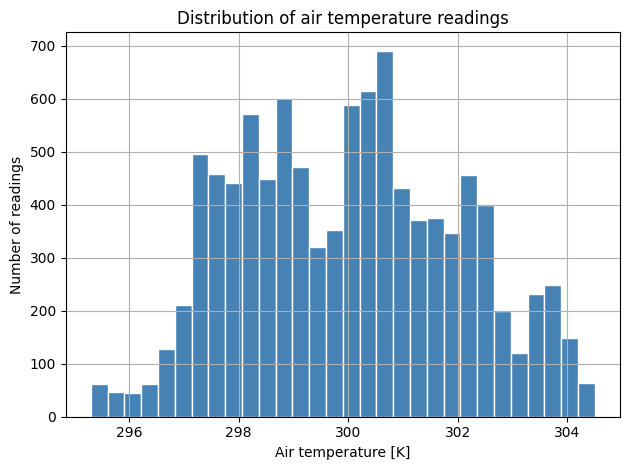

Mean: 300.0
Max:  304.5
Min:  295.3
Spread: 2.0 (std deviation)


In [ ]:
import matplotlib.pyplot as plt

df['Air temperature [K]'].hist(
    bins=30,
    color='steelblue',
    edgecolor='white'
)
plt.xlabel('Air temperature [K]')
plt.ylabel('Number of readings')
plt.title('Distribution of air temperature readings')
plt.tight_layout()
plt.show()

print("Mean:", round(df['Air temperature [K]'].mean(), 2))
print("Max: ", round(df['Air temperature [K]'].max(), 2))
print("Min: ", round(df['Air temperature [K]'].min(), 2))
print("Spread:", round(df['Air temperature [K]'].std(), 1), "(std deviation)")

In [ ]:
print(df['Machine failure'].value_counts(normalize=True).mul(100).round(1))

Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


### Failure rate by machine type

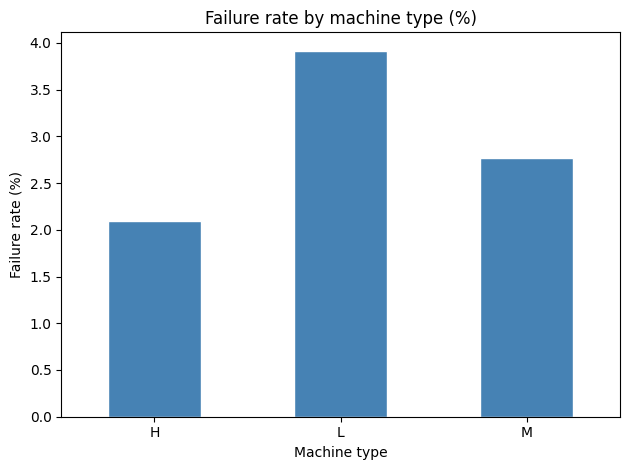

Type
H    2.09
L    3.92
M    2.77
Name: Machine failure, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

failure_by_type = df.groupby('Type')['Machine failure'].mean() * 100

failure_by_type.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Failure rate by machine type (%)')
plt.xlabel('Machine type')
plt.ylabel('Failure rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(failure_by_type.round(2))

### Temperature vs failure (box plot)

The box plot reveals failed machines (median 301.6K) operated
consistently hotter than non-failed machines (median 300.0K).
The 1.6K difference is modest but consistent across the full
distribution, indicating thermal stress is a contributing —
not sole — factor in equipment failure.

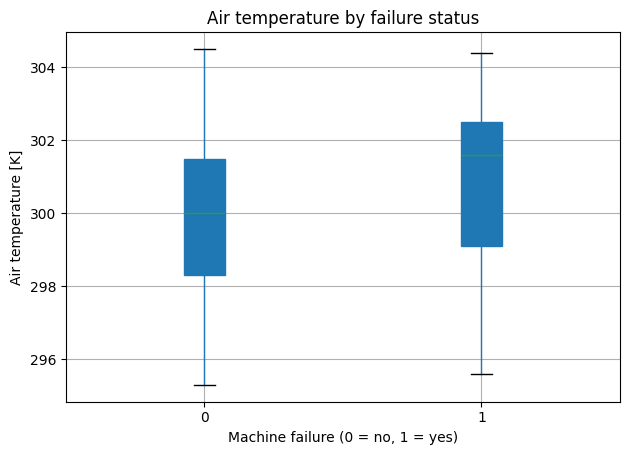

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column='Air temperature [K]', by='Machine failure',
           patch_artist=True)
plt.title('Air temperature by failure status')
plt.suptitle('')
plt.xlabel('Machine failure (0 = no, 1 = yes)')
plt.ylabel('Air temperature [K]')
plt.tight_layout()
plt.show()

In [ ]:
print(df.groupby('Machine failure')['Air temperature [K]'].median())

Machine failure
0    300.0
1    301.6
Name: Air temperature [K], dtype: float64


### Correlation with failure

In [ ]:
corr = df.select_dtypes(include='number').corr()['Machine failure'].sort_values(ascending=False)
print("Correlation with machine failure:")
print(corr.round(3))

Correlation with machine failure:
Machine failure            1.000
HDF                        0.576
OSF                        0.531
PWF                        0.523
TWF                        0.363
Torque [Nm]                0.191
Tool wear [min]            0.105
Air temperature [K]        0.083
Process temperature [K]    0.036
RNF                        0.005
UDI                       -0.023
Rotational speed [rpm]    -0.044
Name: Machine failure, dtype: float64


Torque showed the strongest correlation with failure (0.191) among operational variables, followed by tool wear (0.105) and air temperature (0.083) — suggesting mechanical stress is a stronger failure predictor than thermal conditions alone.

ignoring HDF, OSF, PWF, TWF because they are recorded at the moment of failure, not before it — making them labels, not predictors.

### Z-Score Based Anomaly Detection

In [ ]:
import plotly.express as px
import pandas as pd

from scipy import stats

df['temp_zscore'] = stats.zscore(df['Air temperature [K]'])
df['is_anomaly'] = df['temp_zscore'].abs() > 2

#If the temperature is more than 2 standard deviations away from the average temperature in the dataset, mark it as unusual.

df['anomaly_label'] = df['is_anomaly'].map({False: 'Normal', True: 'Anomaly'})

fig = px.scatter(
    df,
    x=df.index,
    y='Air temperature [K]',
    color='anomaly_label',
    color_discrete_map={'Normal': 'steelblue', 'Anomaly': 'red'},
    opacity=0.6,
    size_max=8,
    title='Temperature anomalies detected via z-score (threshold = 3)',
    labels={
        'x': 'Reading index',
        'Air temperature [K]': 'Air temperature [K]',
        'anomaly_label': 'Status'
    }
)

fig.update_traces(marker=dict(size=4), selector=dict(name='Normal'))
fig.update_traces(marker=dict(size=8), selector=dict(name='Anomaly'))
fig.show()

print(f"Total readings:     {len(df)}")
print(f"Anomalies detected: {df['is_anomaly'].sum()}")
print(f"Anomaly rate:       {round(df['is_anomaly'].mean()*100, 2)}%")

Total readings:     10000
Anomalies detected: 224
Anomaly rate:       2.24%


Threshold sensitivity analysis revealed that air temperature data drifts gradually rather than spiking abruptly, making a strict z-score threshold of 3 unsuitable for this variable. Threshold was adjusted to 2, reflecting the gradual nature of thermal changes in manufacturing environments. In production
systems, threshold selection should be validated against historical failure events rather than set arbitrarily.

### IQR Method Based Anomaly Detection

In [ ]:
Q1 = df['Air temperature [K]'].quantile(0.25)
Q3 = df['Air temperature [K]'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['is_anomaly_iqr'] = (
    (df['Air temperature [K]'] < lower_bound) |
    (df['Air temperature [K]'] > upper_bound)
)

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Anomalies detected (IQR): {df['is_anomaly_iqr'].sum()}")
print(f"Anomaly rate (IQR):       {round(df['is_anomaly_iqr'].mean()*100, 2)}%")

Q1: 298.3, Q3: 301.5, IQR: 3.1999999999999886
Lower bound: 293.5
Upper bound: 306.29999999999995
Anomalies detected (IQR): 0
Anomaly rate (IQR):       0.0%


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Normal readings
normal = df[~df['is_anomaly_iqr']]
anomalies = df[df['is_anomaly_iqr']]

fig.add_trace(go.Scatter(
    x=normal.index,
    y=normal['Air temperature [K]'],
    mode='markers',
    marker=dict(size=3, color='steelblue', opacity=0.5),
    name='Normal'
))

fig.add_trace(go.Scatter(
    x=anomalies.index,
    y=anomalies['Air temperature [K]'],
    mode='markers',
    marker=dict(size=8, color='red'),
    name='Anomaly (IQR)'
))

# Add bound lines
fig.add_hline(y=upper_bound, line_dash='dash',
              line_color='orange', annotation_text='Upper bound')
fig.add_hline(y=lower_bound, line_dash='dash',
              line_color='orange', annotation_text='Lower bound')

fig.update_layout(
    title='Temperature anomalies detected via IQR method',
    xaxis_title='Reading index',
    yaxis_title='Air temperature [K]'
)
fig.show()

In [ ]:
zscore_anomalies = df['is_anomaly'].sum()
iqr_anomalies = df['is_anomaly_iqr'].sum()
both = ((df['is_anomaly']) & (df['is_anomaly_iqr'])).sum()

print("=== Method Comparison ===")
print(f"Z-score anomalies:  {zscore_anomalies}")
print(f"IQR anomalies:      {iqr_anomalies}")
print(f"Flagged by both:    {both}")

=== Method Comparison ===
Z-score anomalies:  224
IQR anomalies:      0
Flagged by both:    0


In [ ]:
print(f"Lower bound: {lower_bound.round(2)}")
print(f"Upper bound: {upper_bound.round(2)}")
print(f"Data min:    {df['Air temperature [K]'].min()}")
print(f"Data max:    {df['Air temperature [K]'].max()}")

Lower bound: 293.5
Upper bound: 306.3
Data min:    295.3
Data max:    304.5


bounds itself are sitting outside data range entirely - meaning the IQR method is saying "everything is normal" because nothing exceeds those wide bounds.

####The fix — reduce the multiplier from 1.5 to 0.75

In [ ]:
multiplier = 0.75

Q1 = df['Air temperature [K]'].quantile(0.25)
Q3 = df['Air temperature [K]'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - multiplier * IQR
upper_bound = Q3 + multiplier * IQR

df['is_anomaly_iqr'] = (
    (df['Air temperature [K]'] < lower_bound) |
    (df['Air temperature [K]'] > upper_bound)
)

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound.round(2)}")
print(f"Upper bound: {upper_bound.round(2)}")
print(f"Anomalies detected (IQR): {df['is_anomaly_iqr'].sum()}")
print(f"Anomaly rate (IQR):       {round(df['is_anomaly_iqr'].mean()*100, 2)}%")

Q1: 298.3, Q3: 301.5, IQR: 3.1999999999999886
Lower bound: 295.9
Upper bound: 303.9
Anomalies detected (IQR): 263
Anomaly rate (IQR):       2.63%


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Normal readings
normal = df[~df['is_anomaly_iqr']]
anomalies = df[df['is_anomaly_iqr']]

fig.add_trace(go.Scatter(
    x=normal.index,
    y=normal['Air temperature [K]'],
    mode='markers',
    marker=dict(size=3, color='steelblue', opacity=0.5),
    name='Normal'
))

fig.add_trace(go.Scatter(
    x=anomalies.index,
    y=anomalies['Air temperature [K]'],
    mode='markers',
    marker=dict(size=8, color='red'),
    name='Anomaly (IQR)'
))

# Add bound lines
fig.add_hline(y=upper_bound, line_dash='dash',
              line_color='orange', annotation_text='Upper bound')
fig.add_hline(y=lower_bound, line_dash='dash',
              line_color='orange', annotation_text='Lower bound')

fig.update_layout(
    title='Temperature anomalies detected via IQR method',
    xaxis_title='Reading index',
    yaxis_title='Air temperature [K]'
)
fig.show()

In [ ]:
zscore_anomalies = df['is_anomaly'].sum()
iqr_anomalies = df['is_anomaly_iqr'].sum()
both = ((df['is_anomaly']) & (df['is_anomaly_iqr'])).sum()

print("=== Method Comparison ===")
print(f"Z-score anomalies:  {zscore_anomalies}")
print(f"IQR anomalies:      {iqr_anomalies}")
print(f"Flagged by both:    {both}")

=== Method Comparison ===
Z-score anomalies:  224
IQR anomalies:      263
Flagged by both:    218


Z-score and IQR methods agreed on 218 anomalies (97% overlap), providing high confidence that flagged readings represent genuine thermal deviations rather than statistical noise. The 6 readings caught by z-score only and 45 caught by IQR only represent
borderline cases that would warrant manual review in a production maintenance system.

###AI-powered anomaly explanations
#### API setup

In [ ]:
!pip install anthropic -q

from google.colab import userdata
import anthropic

client = anthropic.Anthropic(
    api_key=userdata.get('ANTHROPIC_API_KEY')
)

print("Client ready:", client is not None)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.8/923.8 kB 23.5 MB/s eta 0:00:00
Client ready: True


#### Reusable Claude API call function

In [42]:
def call_claude(prompt, num_sentences=2, words_per_sentence=20):
    """
    Input tokens  → calculated based on prompt.
    Output tokens → estimated value. calculated from explicit sentence/word constraints
                   that are also enforced in the prompt itself.
    """
    constrained_prompt = f"""{prompt}
    Write exactly {num_sentences} sentences.
    Each sentence must be {words_per_sentence} words or fewer.
    No bullet points. No headers. No introductory text."""

    token_count = client.messages.count_tokens(
        model="claude-sonnet-4-6",
        messages=[{"role": "user", "content": constrained_prompt}]
    )
    # Token counting is a free operation — no API charges incurred.
    input_tokens = token_count.input_tokens

    # convert words to tokens.
    # 1.3 tokens per word.
    # total words = num_sentences x words_per_sentence
    # add 20% buffer(safety margin) to prevent mid-sentence truncation
    estimated_words = num_sentences * words_per_sentence
    estimated_tokens = estimated_words * 1.3
    safety_margin = estimated_tokens * 0.20
    output_tokens = int(estimated_tokens + safety_margin)

    print(f"Input tokens (exact):     {input_tokens}")
    print(f"Output tokens (estimated): {output_tokens} "
          f"({num_sentences} sentences × {words_per_sentence} words max)")

    # Calculate estimated API cost using Claude Sonnet pricing:
    # Input:  $3.00 per million tokens
    # Output: $15.00 per million tokens
    print(f"Estimated cost: ${((input_tokens * 3) + (output_tokens * 15)) / 1_000_000:.6f}")

    message = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=output_tokens,
        messages=[{"role": "user", "content": constrained_prompt}]
    )

    return {
    "text": message.content[0].text,
    "input_tokens": message.usage.input_tokens,
    "output_tokens": message.usage.output_tokens
    }

#### Anomaly explanation prompt

In [43]:
def explain_anomaly(row):
    prompt = f"""
You are a predictive maintenance expert analyzing manufacturing
sensor data. A temperature anomaly has been detected.

Sensor readings at time of anomaly:
- Air temperature:     {row['Air temperature [K]']}K
- Process temperature: {row['Process temperature [K]']}K
- Torque:              {row['Torque [Nm]']}Nm
- Rotational speed:    {row['Rotational speed [rpm]']}rpm
- Tool wear:           {row['Tool wear [min]']} minutes
- Z-score:             {round(row['temp_zscore'], 2)} standard deviations from mean
- Machine failed:      {'Yes' if row['Machine failure'] == 1 else 'No'}

Write exactly 2 sentences, each under 20 words.
Sentence 1 should state what the anomaly indicates.
Sentence 2 should state what action the maintenance engineer should take.
No bullet points. No headers. No extra text.
"""
    return call_claude(prompt, num_sentences=2, words_per_sentence=20)

#### Selecting top anomalies for explanation

In [44]:
top_anomalies = df[
    (df['is_anomaly']) & (df['is_anomaly_iqr'])
].nlargest(5, 'temp_zscore')[
['Air temperature [K]', 'Process temperature [K]',
     'Torque [Nm]', 'Rotational speed [rpm]',
     'Tool wear [min]', 'temp_zscore', 'Machine failure']
]

print("Top 5 anomalies:")
print(top_anomalies)

Top 5 anomalies:
      Air temperature [K]  Process temperature [K]  Torque [Nm]  \
5145                304.5                    313.7         32.9   
5139                304.4                    313.6         38.9   
5141                304.4                    313.7         35.0   
5142                304.4                    313.6         39.1   
5144                304.4                    313.7         33.5   

      Rotational speed [rpm]  Tool wear [min]  temp_zscore  Machine failure  
5145                    1670                7     2.247357                0  
5139                    1510              199     2.197361                0  
5141                    1509              205     2.197361                1  
5142                    1568                0     2.197361                0  
5144                    1607                5     2.197361                0  


#### Generating explanations and tracking actual cost

In [45]:
import time

explanations = []
running_input_tokens = 0
running_output_tokens = 0

for idx, row in top_anomalies.iterrows():
    print(f"\n--- Analyzing reading {idx} ---")
    result = explain_anomaly(row)
    explanation = result["text"]

    running_input_tokens += result["input_tokens"]
    running_output_tokens += result["output_tokens"]

    explanations.append({
        'Reading':        idx,
        'Temperature(K)': row['Air temperature [K]'],
        'Torque(Nm)':     row['Torque [Nm]'],
        'Tool wear(min)': row['Tool wear [min]'],
        'Z-Score':        round(row['temp_zscore'], 2),
        'Failed':         'Yes' if row['Machine failure'] == 1 else 'No',
        'Explanation':    explanation
    })

    time.sleep(1)  # small pause between calls — avoids rate limiting

# Display results
results_df = pd.DataFrame(explanations)

print("\n\n=== AI-Generated Anomaly Explanations ===\n")
for _, r in results_df.iterrows():
    print(f"Reading {r['Reading']} | "
          f"Temp: {r['Temperature(K)']}K | "
          f"Z-Score: {r['Z-Score']} | "
          f"Failed: {r['Failed']}")
    print(f"→ {r['Explanation']}")
    print("-" * 60)


--- Analyzing reading 5145 ---
Input tokens (exact):     215
Output tokens (estimated): 62 (2 sentences × 20 words max)
Estimated cost: $0.001575

--- Analyzing reading 5139 ---
Input tokens (exact):     215
Output tokens (estimated): 62 (2 sentences × 20 words max)
Estimated cost: $0.001575

--- Analyzing reading 5141 ---
Input tokens (exact):     215
Output tokens (estimated): 62 (2 sentences × 20 words max)
Estimated cost: $0.001575

--- Analyzing reading 5142 ---
Input tokens (exact):     215
Output tokens (estimated): 62 (2 sentences × 20 words max)
Estimated cost: $0.001575

--- Analyzing reading 5144 ---
Input tokens (exact):     215
Output tokens (estimated): 62 (2 sentences × 20 words max)
Estimated cost: $0.001575


=== AI-Generated Anomaly Explanations ===

Reading 5145 | Temp: 304.5K | Z-Score: 2.25 | Failed: No
→ The temperature anomaly shows elevated process heat at 2.25 standard deviations, signaling potential thermal stress. Schedule an inspection soon to check cooling

In [46]:
total_cost = ((running_input_tokens * 3) +
              (running_output_tokens * 15)) / 1_000_000

print(f"Total input tokens (actual):  {running_input_tokens}")
print(f"Total output tokens (actual): {running_output_tokens}")
print(f"Total tokens used:            {running_input_tokens + running_output_tokens}")
print(f"Total cost:                   ${total_cost:.6f}")

Total input tokens (actual):  1075
Total output tokens (actual): 210
Total tokens used:            1285
Total cost:                   $0.006375
